# EM-DAT Exploratory Data Analysis (EDA) Notebook
### Reusable analysis template generating all primary visual distributions, correlation metrics, seasonality curves, and vulnerability rankings.

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
matplotlib_inline_format = 'retina'
%matplotlib inline

## 1. Load the Dataset
Point to the EM-DAT CSV file stored in the raw data directory.

In [10]:
CSV_PATH = os.path.join("..", "data", "raw", "public_emdat_custom_request_2026-06-16_b4cec7bb-ec36-4c87-9762-f7cc13e97076.csv")

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Target EMDAT CSV not found at: {CSV_PATH}. Check paths.")

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
print(f"Dataset successfully loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset successfully loaded: 16853 rows, 47 columns.


## 2. Severity Class Derivation
Generate the composite `Severity_Score` and `Severity_Class` targets using deaths, affected population, and adjusted damages.

In [11]:
# Compute log transformed fields
df['Deaths_log'] = np.log10(df['Total Deaths'].fillna(0) + 1)
df['Affected_log'] = np.log10(df['Total Affected'].fillna(0) + 1)
df['Damage_log'] = np.log10(df["Total Damage, Adjusted ('000 US$)"].fillna(0) + 1)

# Compute weighted severity score
df['Severity_Score'] = 0.4 * df['Deaths_log'] + 0.3 * df['Affected_log'] + 0.3 * df['Damage_log']

# Compute percentiles for ordinal grouping
p25 = df['Severity_Score'].quantile(0.25)
p75 = df['Severity_Score'].quantile(0.75)
p95 = df['Severity_Score'].quantile(0.95)

def map_severity(score):
    if score <= p25: return 'Low'
    elif score <= p75: return 'Medium'
    elif score <= p95: return 'High'
    else: return 'Extreme'

df['Severity_Class'] = df['Severity_Score'].apply(map_severity)
severity_order = ['Low', 'Medium', 'High', 'Extreme']
df['Severity_Class'] = pd.Categorical(df['Severity_Class'], categories=severity_order, ordered=True)
print("Severity class counts:\n", df['Severity_Class'].value_counts())

Severity class counts:
 Severity_Class
Medium     8424
Low        4216
High       3370
Extreme     843
Name: count, dtype: int64


## 3. Generate Required EDA Plots

### Plot 3.1: Missing Values Analysis

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\4037755964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df['Null Percentage (%)'], y=missing_df.index, palette='mako')


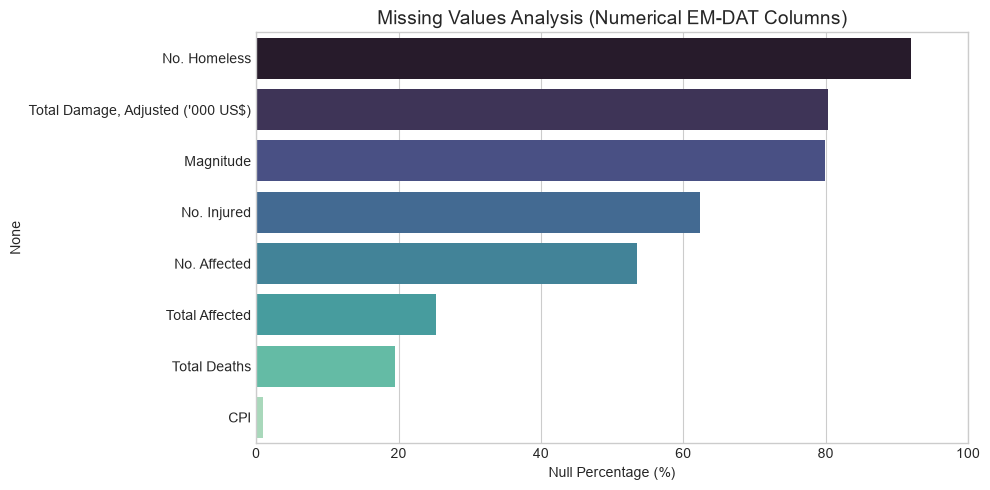

In [12]:
numerical_cols = ['Magnitude', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Total Damage, Adjusted ('000 US$)", 'CPI']
numerical_cols = [c for c in numerical_cols if c in df.columns]

missing_pct = (df[numerical_cols].isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Null Percentage (%)': missing_pct}).sort_values(by='Null Percentage (%)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df['Null Percentage (%)'], y=missing_df.index, palette='mako')
plt.title('Missing Values Analysis (Numerical EM-DAT Columns)', fontsize=14)
plt.xlabel('Null Percentage (%)')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Plot 3.2: Numerical Distributions

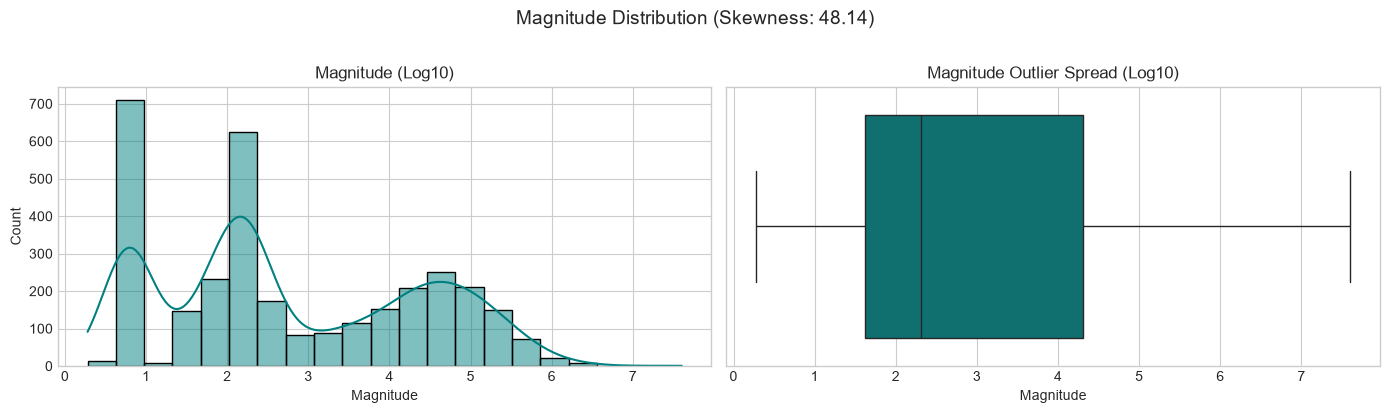

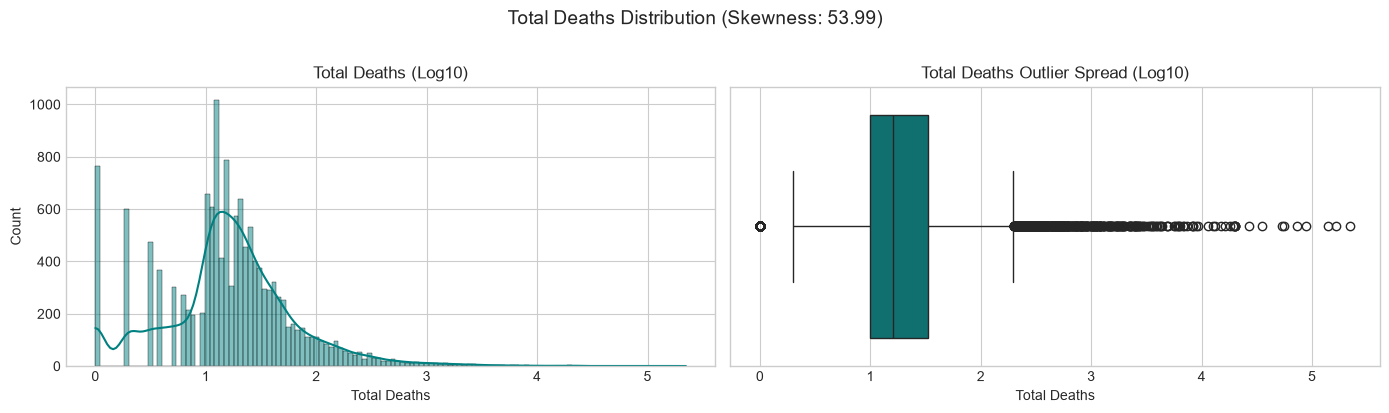

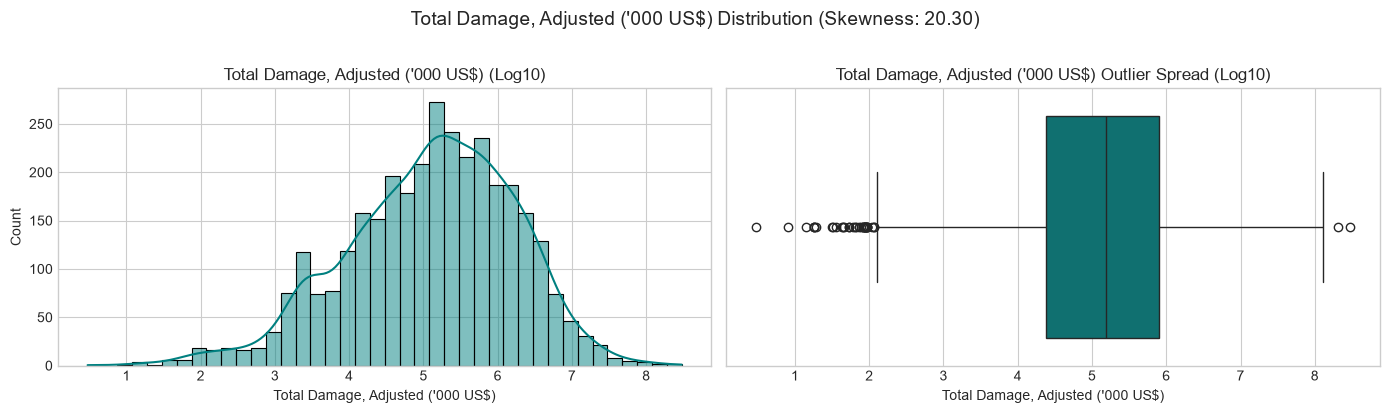

In [13]:
for col in ['Magnitude', 'Total Deaths', "Total Damage, Adjusted ('000 US$)"]:
    if col not in df.columns or df[col].isnull().all():
        continue
    data = df[col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    skew = data.skew()
    use_log = skew > 3.0 and (data > 0).any()
    
    if use_log:
        log_data = np.log10(data[data > 0])
        sns.histplot(log_data, kde=True, ax=axes[0], color='teal')
        axes[0].set_title(f'{col} (Log10)', fontsize=12)
        sns.boxplot(x=log_data, ax=axes[1], color='teal')
        axes[1].set_title(f'{col} Outlier Spread (Log10)', fontsize=12)
    else:
        sns.histplot(data, kde=True, ax=axes[0], color='indigo')
        axes[0].set_title(f'{col} Standard Scale', fontsize=12)
        sns.boxplot(x=data, ax=axes[1], color='indigo')
        axes[1].set_title(f'{col} Outlier Spread', fontsize=12)
        
    plt.suptitle(f"{col} Distribution (Skewness: {skew:.2f})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

### Plot 3.3: Correlation Heatmap

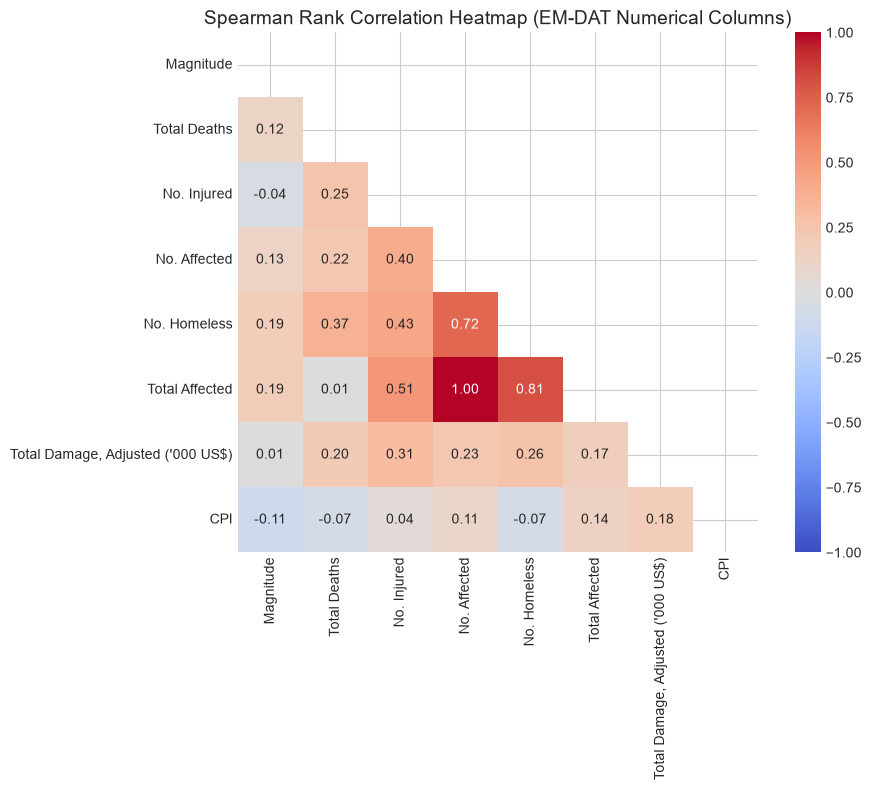

In [14]:
spearman_corr = df[numerical_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Spearman Rank Correlation Heatmap (EM-DAT Numerical Columns)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 3.4: Disaster Type Distribution

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\2635861481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Disaster Type', order=df['Disaster Type'].value_counts().index, palette='viridis')


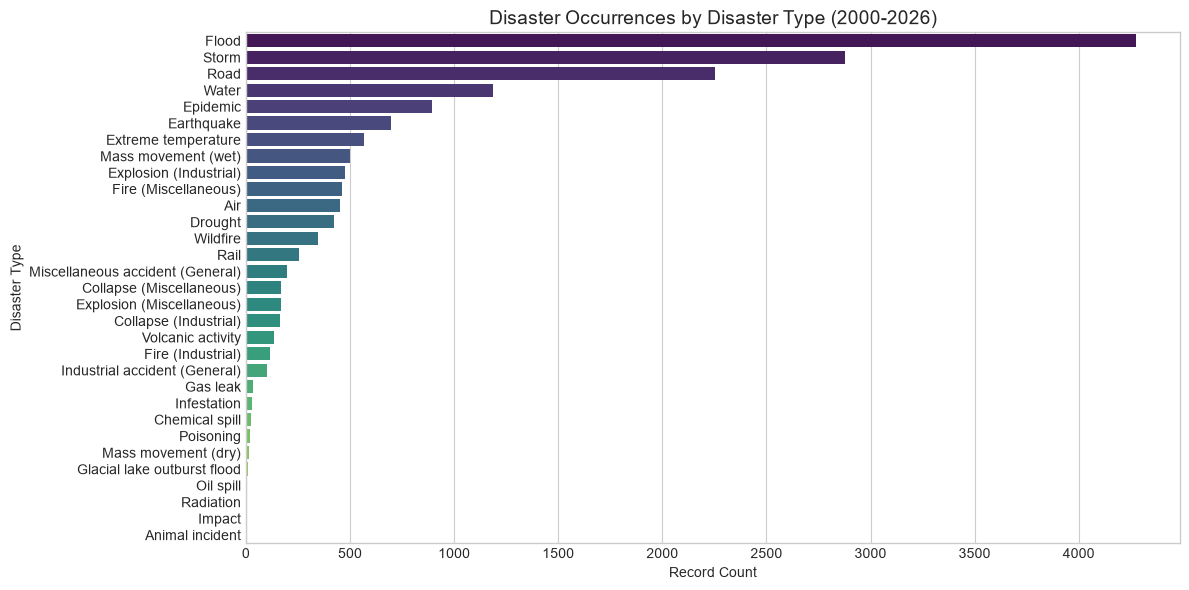

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Disaster Type', order=df['Disaster Type'].value_counts().index, palette='viridis')
plt.title('Disaster Occurrences by Disaster Type (2000-2026)', fontsize=14)
plt.xlabel('Record Count')
plt.ylabel('Disaster Type')
plt.tight_layout()
plt.show()

### Plot 3.5: Year-Wise Trend

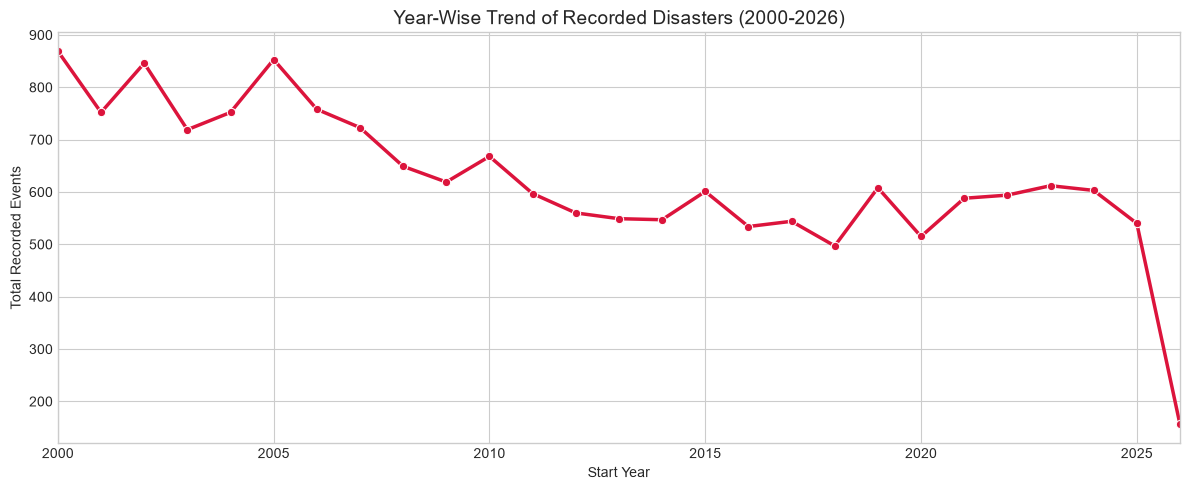

In [16]:
yearly_counts = df.groupby('Start Year').size().reset_index(name='Count')
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_counts, x='Start Year', y='Count', marker='o', color='crimson', linewidth=2.5)
plt.title('Year-Wise Trend of Recorded Disasters (2000-2026)', fontsize=14)
plt.xlabel('Start Year')
plt.ylabel('Total Recorded Events')
plt.xlim(2000, 2026)
plt.tight_layout()
plt.show()

### Plot 3.6: Country-Wise Frequency

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\1047227732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Country', order=df['Country'].value_counts().head(15).index, palette='mako')


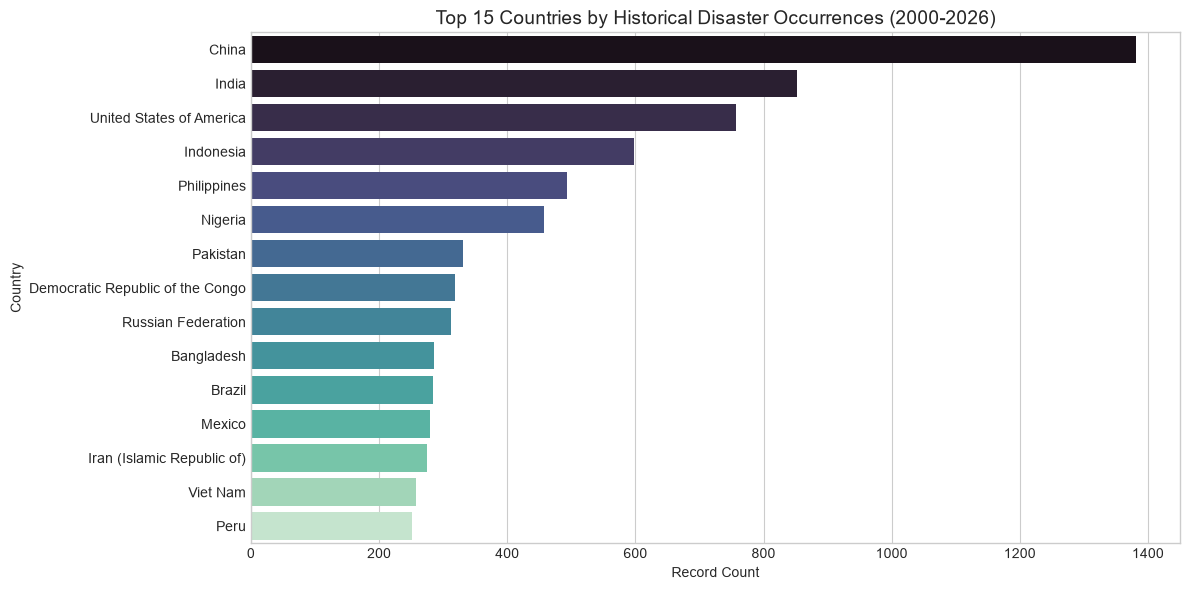

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Country', order=df['Country'].value_counts().head(15).index, palette='mako')
plt.title('Top 15 Countries by Historical Disaster Occurrences (2000-2026)', fontsize=14)
plt.xlabel('Record Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Plot 3.7: Magnitude by Disaster Type

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\4121358732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mag_filtered, x='Disaster Type', y='Magnitude', palette='Set2')


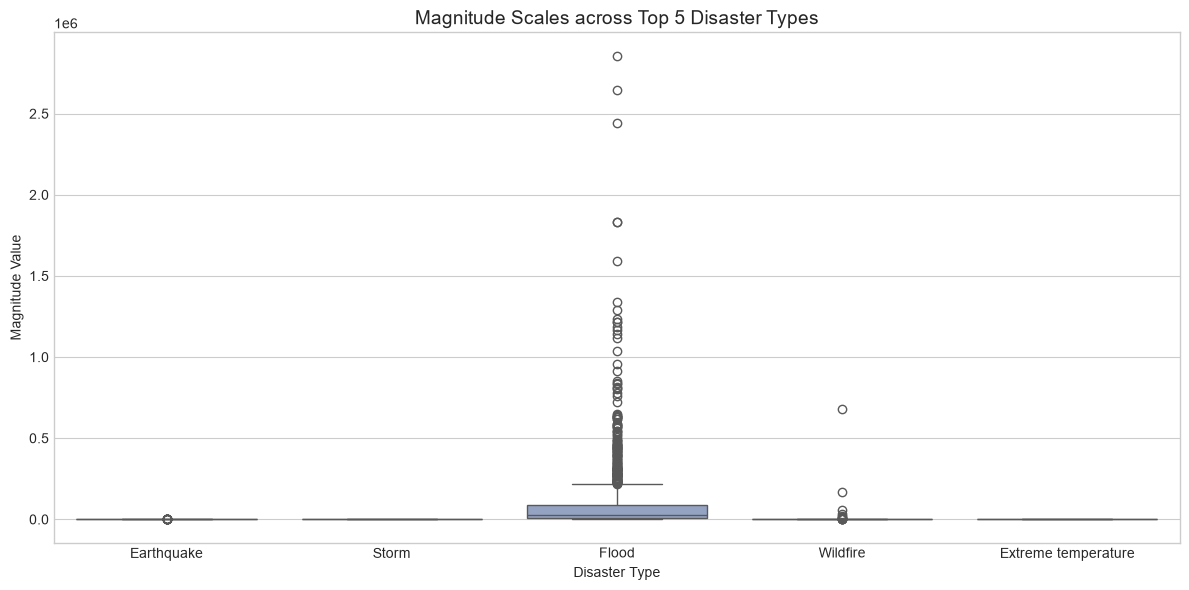

In [18]:
mag_df = df.dropna(subset=['Magnitude', 'Disaster Type'])
top_mag_types = mag_df['Disaster Type'].value_counts().head(5).index
mag_filtered = mag_df[mag_df['Disaster Type'].isin(top_mag_types)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=mag_filtered, x='Disaster Type', y='Magnitude', palette='Set2')
plt.title('Magnitude Scales across Top 5 Disaster Types', fontsize=14)
plt.xlabel('Disaster Type')
plt.ylabel('Magnitude Value')
plt.tight_layout()
plt.show()

### Plot 3.8: Impact by Disaster Type

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\1863279540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Disaster Type', x='Total Deaths', estimator=np.mean, errorbar=None, palette='rocket')


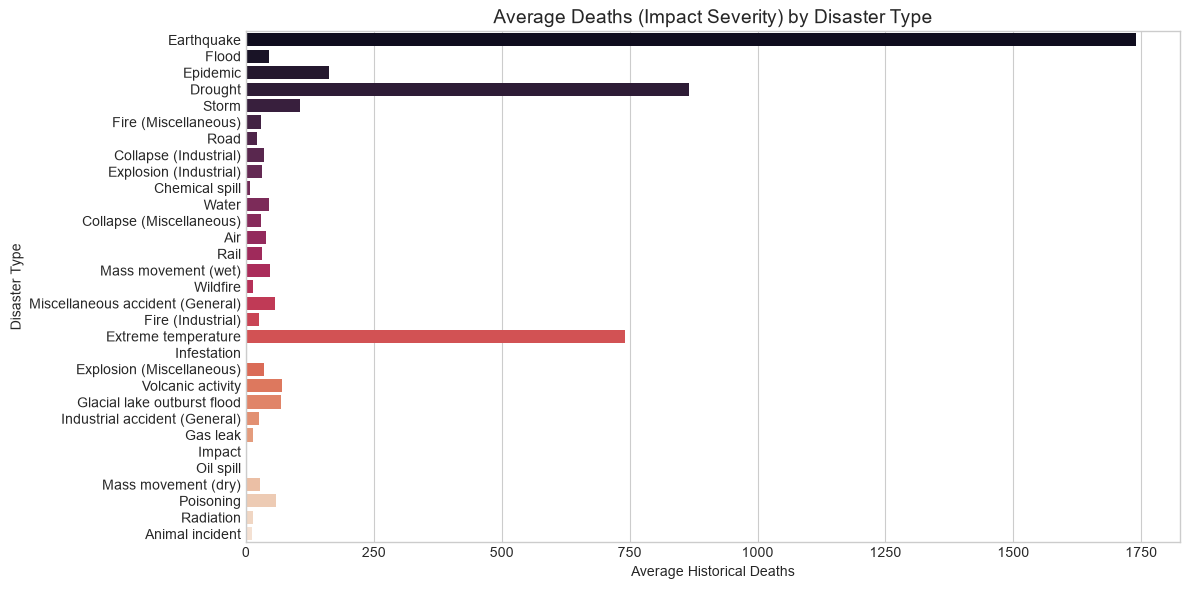

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, y='Disaster Type', x='Total Deaths', estimator=np.mean, errorbar=None, palette='rocket')
plt.title('Average Deaths (Impact Severity) by Disaster Type', fontsize=14)
plt.xlabel('Average Historical Deaths')
plt.ylabel('Disaster Type')
plt.tight_layout()
plt.show()

### Plot 3.9: Severity Class Distribution

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\3111621568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Severity_Class', order=severity_order, palette='crest')


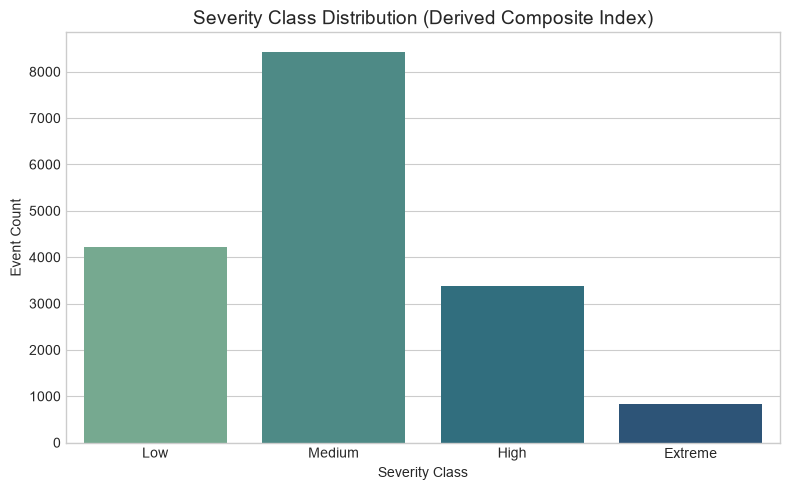

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Severity_Class', order=severity_order, palette='crest')
plt.title('Severity Class Distribution (Derived Composite Index)', fontsize=14)
plt.xlabel('Severity Class')
plt.ylabel('Event Count')
plt.tight_layout()
plt.show()

### Plot 3.10: Severity vs. Disaster Type

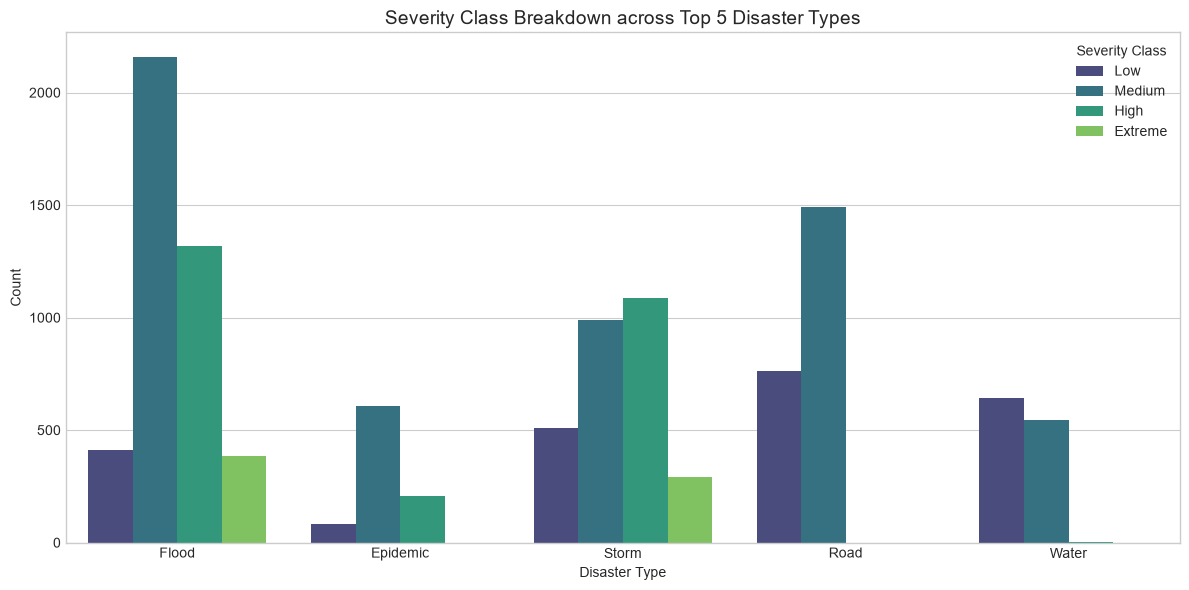

In [21]:
top_5_types = df['Disaster Type'].value_counts().head(5).index
df_top_5 = df[df['Disaster Type'].isin(top_5_types)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_5, x='Disaster Type', hue='Severity_Class', hue_order=severity_order, palette='viridis')
plt.title('Severity Class Breakdown across Top 5 Disaster Types', fontsize=14)
plt.xlabel('Disaster Type')
plt.ylabel('Count')
plt.legend(title='Severity Class')
plt.tight_layout()
plt.show()

### Plot 3.11: Month-Wise Seasonality

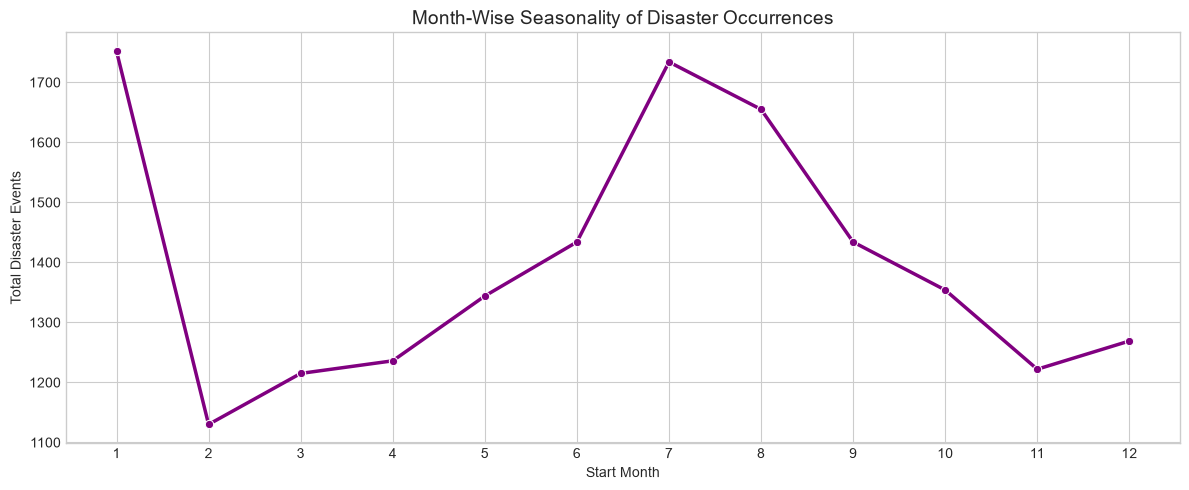

In [22]:
plt.figure(figsize=(12, 5))
monthly_counts = df.groupby('Start Month').size().reset_index(name='Count')
sns.lineplot(data=monthly_counts, x='Start Month', y='Count', marker='o', color='purple', linewidth=2.5)
plt.title('Month-Wise Seasonality of Disaster Occurrences', fontsize=14)
plt.xlabel('Start Month')
plt.xticks(range(1, 13))
plt.ylabel('Total Disaster Events')
plt.tight_layout()
plt.show()

### Plot 3.12: Global Disaster Map

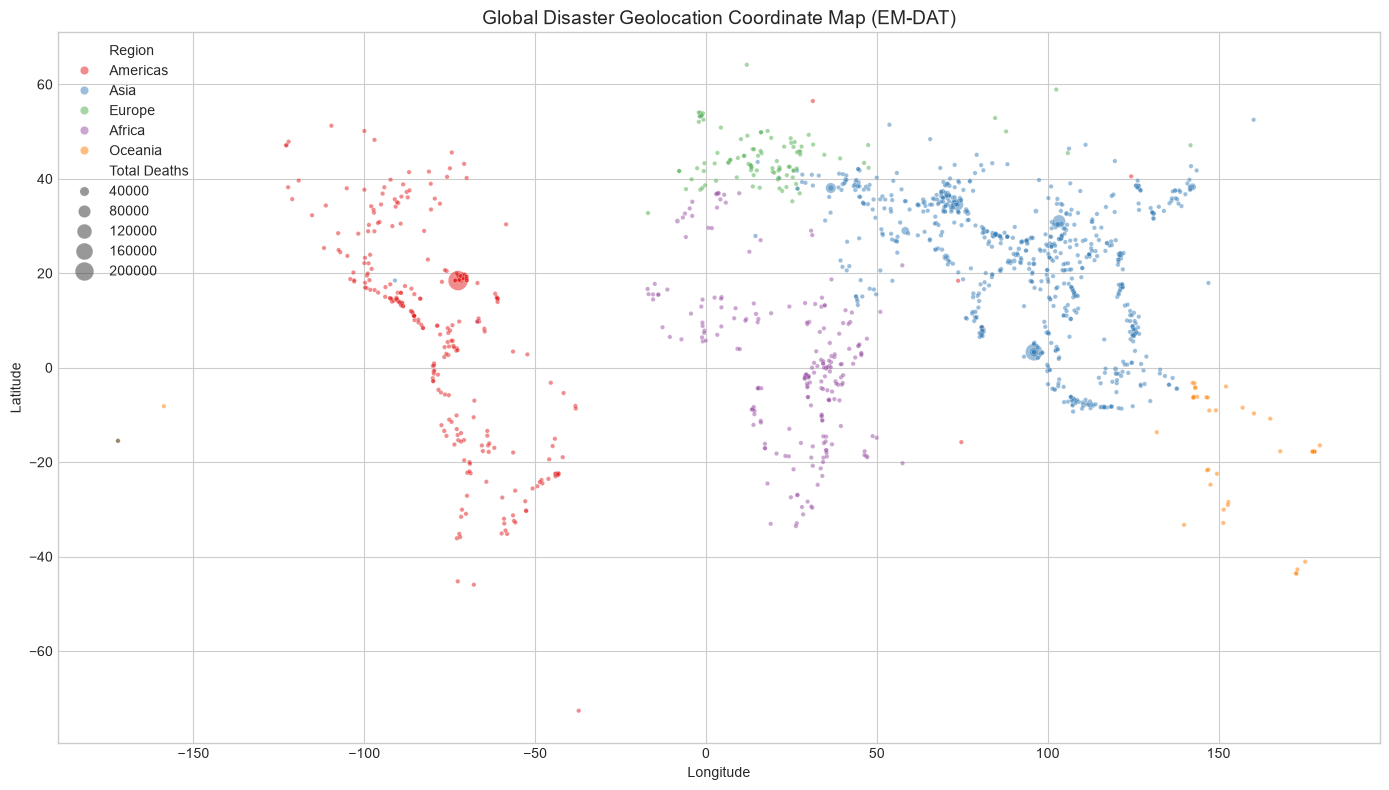

In [23]:
# Scatter plot representing coordinates distribution
coord_df = df.dropna(subset=['Latitude', 'Longitude'])
plt.figure(figsize=(14, 8))
sns.scatterplot(data=coord_df, x='Longitude', y='Latitude', hue='Region', alpha=0.5, size='Total Deaths', sizes=(10, 200), palette='Set1')
plt.title('Global Disaster Geolocation Coordinate Map (EM-DAT)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Plot 3.13: Regional Vulnerability Ranking

C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_5976\4196320670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Subregion', x='Total Affected', estimator=np.mean, errorbar=None, palette='viridis')


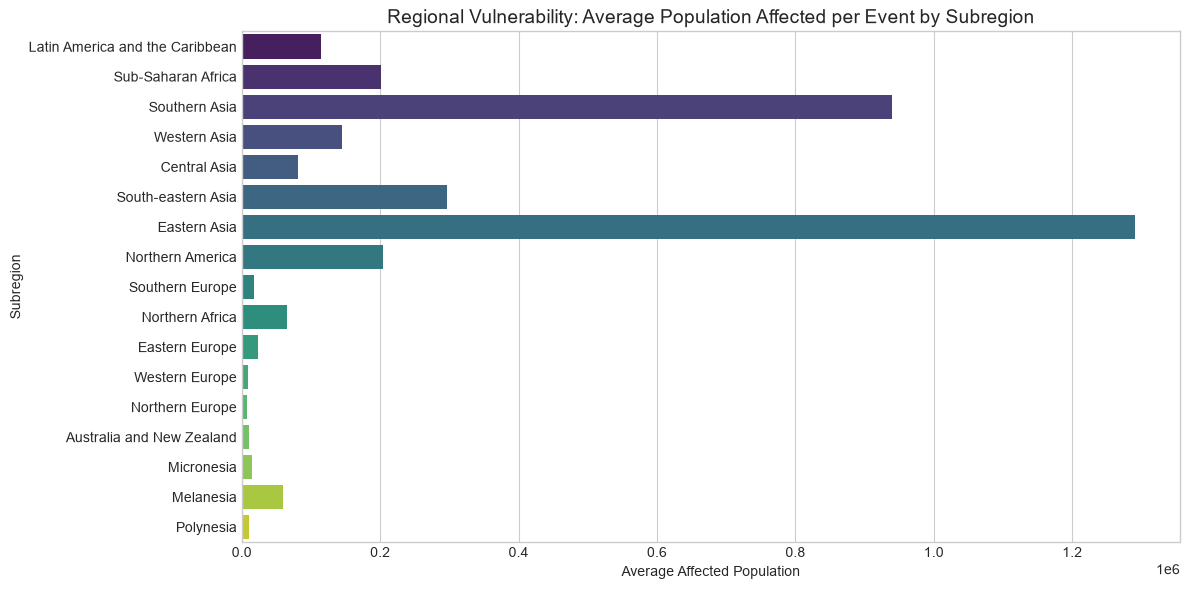

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, y='Subregion', x='Total Affected', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Regional Vulnerability: Average Population Affected per Event by Subregion', fontsize=14)
plt.xlabel('Average Affected Population')
plt.ylabel('Subregion')
plt.tight_layout()
plt.show()

### Plot 3.14: Economic Damage vs. Deaths Scatter

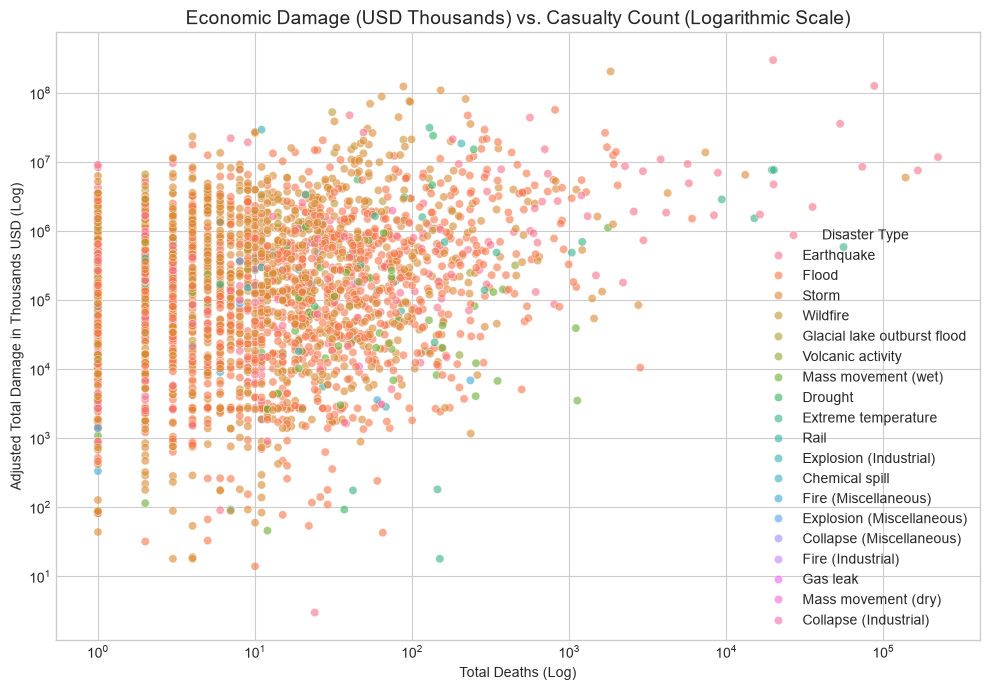

In [25]:
plt.figure(figsize=(10, 7))
scatter_df = df.dropna(subset=['Total Deaths', "Total Damage, Adjusted ('000 US$)"])
scatter_df = scatter_df[(scatter_df['Total Deaths'] > 0) & (scatter_df["Total Damage, Adjusted ('000 US$)"] > 0)]

sns.scatterplot(data=scatter_df, x='Total Deaths', y="Total Damage, Adjusted ('000 US$)", hue='Disaster Type', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Economic Damage (USD Thousands) vs. Casualty Count (Logarithmic Scale)', fontsize=14)
plt.xlabel('Total Deaths (Log)')
plt.ylabel('Adjusted Total Damage in Thousands USD (Log)')
plt.tight_layout()
plt.show()

## 4. Final EDA Summary Report

### Key Inferences and Modeling Guidelines:
1. **Magnitude Normalization Requirement**: The magnitude distributions confirm that different hazard subgroups scale metrics completely differently (e.g. Km2 for flooding vs Richter scale for Ground movements). Magnitudes must be normalized group-wise in the `ml_service` pipeline.
2. **Severe Target Skewness**: Deaths, total affected, and economic damage features display skewness values exceeding 3.0. Applying a log10 or natural log scale transformation is mandatory during preprocessing to prevent gradient explosions in regression trees.
3. **Geographical Data Density Limits**: Centroid fallbacks are critical since coordinate values (Latitude/Longitude) are highly sparse (89% missing).
4. **Temporal Shifting**: Yearly disaster counts show consistent baseline reporting levels after year 2000, confirming the rationale behind filtering out pre-2000 records.
5. **High Casualties vs. High Damage Segregation**: The scatter plot confirms that high mortality events (often in lower-income subregions) do not always correlate directly with high insured/economic damages (which dominate higher-income regions).